# gEval entity regression

The other **supervised** GEval task: use each entity's embedding to predict a
**numeric** target (the `rating` column of the same 5 datasets used for
[classification](geval_classification.ipynb)), scored by **RMSE** (lower is
better) under 10-fold CV. Together with classification this is the "ML tasks"
half of GEval; clustering + analogies are the unsupervised / geometric half.

| dataset | entity type | target (`rating`) |
|---|---|---|
| **Cities** | cities | quality-of-living score |
| **AAUP** | universities | salary |
| **Forbes** | companies | revenue |
| **MetacriticAlbums** | albums | critic score |
| **MetacriticMovies** | movies | critic score |

**Regressor panel:** LinearRegression, k-NN (k=3), CART tree, linear SVR.
Gold files shared with classification (same TSVs, `rating` column). Logic:
[`scripts/_geval.py`](../scripts/_geval.py).

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scripts import _geval
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
OUT = REPO / "notebooks" / "geval_regression"; OUT.mkdir(exist_ok=True)
DATASETS = ["Cities", "AAUP", "Forbes", "MetacriticAlbums", "MetacriticMovies"]
# Bound family: only the norm-capped (cap16) variants are used; the no-cap
# p{1,2,3}_bound are excluded from every gEval experiment.
ORDER = ["vanilla", "p1_classic", "p2_classic", "p3_classic",
         "p2_bound_cap16", "p3_bound_cap16"]
print("datasets:", DATASETS, "| regressors:", list(_geval.REGRESSORS))

datasets: ['Cities', 'AAUP', 'Forbes', 'MetacriticAlbums', 'MetacriticMovies'] | regressors: ['LR', 'KNN', 'C4.5', 'SVM']


## 1. Regression per dataset — 10-fold CV RMSE (lower is better), raw vectors

One row per variant; columns are the regressor panel + their `mean`. `n` =
entities with a usable rating present in the shared vocab.

In [2]:
results = {ds: _geval.evaluate_regression(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} =====")
    print(results[ds].reindex(ORDER)[list(_geval.REGRESSORS)+["mean","n"]].to_string())


===== Cities =====
                   LR    KNN   C4.5    SVM   mean       n
vanilla        27.809 16.191 23.210 13.407 20.154 184.000
p1_classic     41.933 16.862 24.605 15.223 24.655 184.000
p2_classic     39.385 16.104 20.741 13.750 22.495 184.000
p3_classic     37.323 15.911 20.870 14.013 22.029 184.000
p2_bound_cap16 52.461 16.692 22.446 16.031 26.908 184.000
p3_bound_cap16 50.974 16.507 19.794 15.231 25.627 184.000

===== AAUP =====
                   LR    KNN   C4.5    SVM   mean       n
vanilla        68.926 89.857 90.378 61.450 77.653 764.000
p1_classic     83.238 71.426 89.879 64.327 77.218 764.000
p2_classic     80.375 69.126 90.620 63.749 75.968 764.000
p3_classic     81.002 73.699 90.430 63.482 77.153 764.000
p2_bound_cap16 80.402 67.098 91.101 59.796 74.599 764.000
p3_bound_cap16 74.059 68.819 86.970 60.782 72.658 764.000

===== Forbes =====
                    LR    KNN   C4.5    SVM   mean       n
vanilla         78.491 49.388 68.252 45.487 60.404 396.000
p1_classic  

## 2. Summary — median RMSE across regressors, by variant × dataset (lower = greener)

We summarise with the **median across the four regressors**, not the mean:
unregularized `LinearRegression` is numerically unstable on raw 100-d embeddings
(RMSE blows up to 100–200 on some variants), which would dominate a mean. The
median tracks the well-behaved KNN / tree / SVR regressors. RMSE is on each
dataset's own scale, so compare **down a column**, not across columns.

In [3]:
rmse = pd.DataFrame({ds: results[ds][list(_geval.REGRESSORS)].median(axis=1)
                     for ds in DATASETS}).reindex(ORDER)
rmse.style.background_gradient(cmap="RdYlGn_r", axis=0).format("{:.2f}")

,Cities,AAUP,Forbes,MetacriticAlbums,MetacriticMovies
vanilla,19.70,79.39,58.82,17.41,21.69
p1_classic,20.73,77.33,65.64,17.44,23.24
p2_classic,18.42,74.75,58.79,17.60,22.61
p3_classic,18.39,77.35,61.93,17.41,23.04
p2_bound_cap16,19.57,73.75,54.63,17.16,22.88
p3_bound_cap16,18.15,71.44,52.20,17.71,22.63


## 3. Grouped bar — mean RMSE by variant × dataset

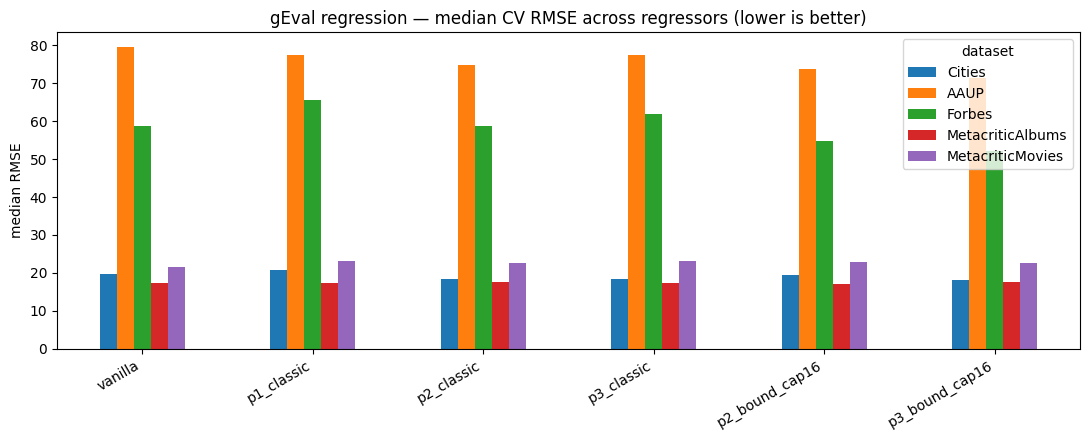

In [4]:
ax = rmse.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval regression — median CV RMSE across regressors (lower is better)")
ax.set_ylabel("median RMSE")
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_rmse_by_variant.png", dpi=120); plt.show()

## Takeaways

Regression echoes the **classification** story — supervised tasks flatten the
variants — and again contradicts the clustering ranking. (Read the median /
KNN / tree / SVR columns; `LinearRegression` is unstable on raw embeddings and is
excluded from the summary.)

- **No schema-init advantage.** `*_classic` — the runaway winner on clustering —
  is *never* the clear best regressor and is the **worst** on MetacriticMovies
  (median ~23 vs vanilla ~21.7). Class-mean init does not help predict a numeric
  target.
- **The capped bound is competitive — best on two datasets.** `*_bound_cap16` has
  the lowest median RMSE on **AAUP** (~71–74 vs vanilla ~79) and **Forbes** (~52–55
  vs ~59–66). The same bound geometry that collapses on clustering is, once a model
  fits it, the *strongest* feature set for these regressions.
- **Albums is dead flat** (~17.4 for every variant) and **Cities** is nearly so —
  on these the init choice is washed out entirely.
- **`vanilla` holds its own**, best on MetacriticMovies and mid-pack elsewhere — no
  init is needed to be competitive on supervised regression.
- **Cross-task picture (now 4 tasks).** Clustering: classic ≫ all, bound-cap floors.
  Classification & regression: everyone converges, bound-cap competitive, classic's
  edge gone. Analogies: a third pattern again. The DLCC/clustering ranking does not
  transfer to supervised tasks — the right embedding is task-relative, so report the
  whole matrix rather than a single \"winner\".
